LOGISTIC REGRESSION ON TITANIC DATASET

USING FEATURES SUCH AS PCLASS, AGE, SEX, AND EMBARKED TO PREDICT SURVIVAL RATE

In [ ]:
# IMPORTING LIBRARY AND LOADING DATA
import pandas as pd

data = pd.read_csv(r"C:\Users\USER\Downloads\Titanic-Dataset.csv")
data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [ ]:
# SELECT RELEVANT FEATURES FOR MODELING
columns_to_use = ["Survived", "Pclass", "Sex", "Age", "Embarked"]
new_data = data.loc[:, columns_to_use]
new_data

,Survived,Pclass,Sex,Age,Embarked
0,0,3,male,22.0,S
1,1,1,female,38.0,C
2,1,3,female,26.0,S
3,1,1,female,35.0,S
4,0,3,male,35.0,S
...,...,...,...,...,...
886,0,2,male,27.0,S
887,1,1,female,19.0,S
888,0,3,female,NaN,S
889,1,1,male,26.0,C


In [ ]:
# HANDLE MISSING VALUES (DROP NULL ROWS)
new_data.dropna(inplace=True)

In [ ]:
# CHECK DATA STRUCTURE AND DATA TYPES
new_data.info()

<class 'pandas.DataFrame'>
Index: 712 entries, 0 to 890
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  712 non-null    int64  
 1   Pclass    712 non-null    int64  
 2   Sex       712 non-null    str    
 3   Age       712 non-null    float64
 4   Embarked  712 non-null    str    
dtypes: float64(1), int64(2), str(2)
memory usage: 33.4 KB


In [ ]:
# SUMMARY STATISTICS FOR AGE FEATURE
new_data["Age"].describe()

count    712.000000
mean      29.642093
std       14.492933
min        0.420000
25%       20.000000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

In [ ]:
# FILTER ROWS WITH SPECIFIC AGE VALUE (0.42)
new_data[new_data["Age"]== 0.42]

,Survived,Pclass,Sex,Age,Embarked
803,1,3,male,0.42,C


In [ ]:
# FEATURE ENGINEERING: CREATE AGE GROUP CATEGORIES
bins = [0, 18, 50, 80]
labels = ["Child", "Adult", "Senior"]
new_data["AgeGroup"] = pd.cut(new_data["Age"], bins = bins, labels = labels, include_lowest= True )

In [ ]:
# DISPLAY UPDATED DATASET
new_data

,Survived,Pclass,Sex,Age,Embarked,AgeGroup
0,0,3,male,22.0,S,Adult
1,1,1,female,38.0,C,Adult
2,1,3,female,26.0,S,Adult
3,1,1,female,35.0,S,Adult
4,0,3,male,35.0,S,Adult
...,...,...,...,...,...,...
885,0,3,female,39.0,Q,Adult
886,0,2,male,27.0,S,Adult
887,1,1,female,19.0,S,Adult
889,1,1,male,26.0,C,Adult


In [ ]:
# DROP ORIGINAL AGE COLUMN AFTER CREATING AGE GROUP
new_data.drop("Age", axis =1, inplace = True)

In [ ]:
# DISPLAY UPDATED DATASET
new_data

,Survived,Pclass,Sex,Embarked,AgeGroup
0,0,3,male,S,Adult
1,1,1,female,C,Adult
2,1,3,female,S,Adult
3,1,1,female,S,Adult
4,0,3,male,S,Adult
...,...,...,...,...,...
885,0,3,female,Q,Adult
886,0,2,male,S,Adult
887,1,1,female,S,Adult
889,1,1,male,C,Adult


In [ ]:
# ENCODE CATEGORICAL FEATURES USING ONE-HOT ENCODING
from sklearn.preprocessing import OneHotEncoder
categorical_features = ["Pclass", "Sex", "Embarked", "AgeGroup"]
categorical_encoder = OneHotEncoder(sparse_output= False)

In [ ]:
# APPLY COLUMN TRANSFORMER TO ENCODE CATEGORICAL FEATURES
from sklearn.compose import ColumnTransformer
ct = ColumnTransformer(transformers=[
    ("cat", categorical_encoder, categorical_features)
    ])
ct.set_output(transform="pandas")
encoded_features = ct.fit_transform(new_data)

In [ ]:
# ENCODE TARGET VARIABLE (SURVIVAL OUTCOME)
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
encoded_label = label_encoder.fit_transform(new_data["Survived"])

In [ ]:
# COMBINE ENCODED FEATURES WITH TARGET VARIABLE
encoded_new_data = encoded_features.assign(Survived = encoded_label)

In [ ]:
# DISPLAY UPDATED DATASET
encoded_new_data

,cat__Pclass_1,cat__Pclass_2,cat__Pclass_3,cat__Sex_female,cat__Sex_male,cat__Embarked_C,cat__Embarked_Q,cat__Embarked_S,cat__AgeGroup_Adult,cat__AgeGroup_Child,cat__AgeGroup_Senior,Survived
0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0
1,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1
2,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1
3,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1
4,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
885,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0
886,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0
887,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1
889,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1


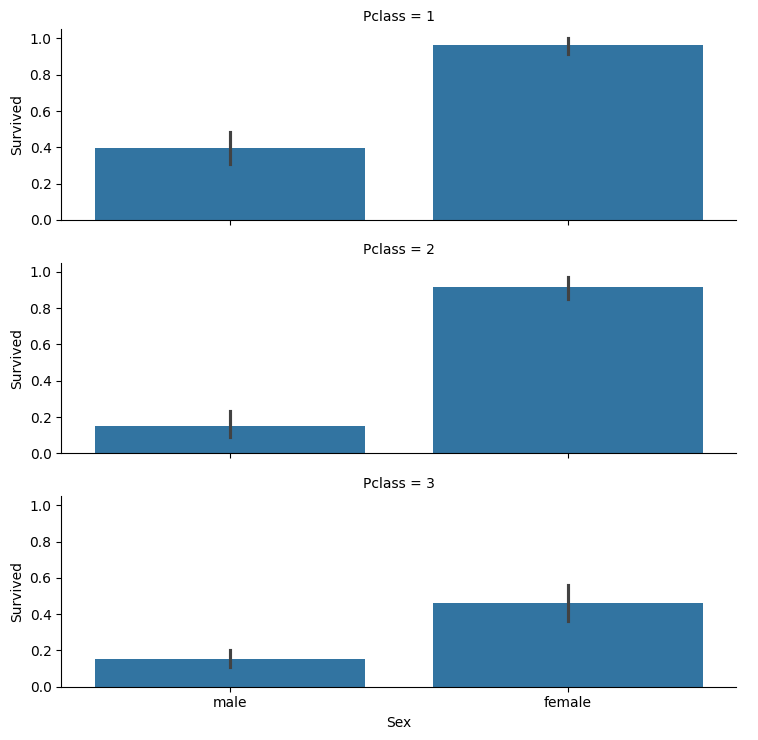

In [ ]:
# VISUALIZE SURVIVAL RATE BY GENDER AND PASSENGER CLASS
import seaborn as sns
import matplotlib.pyplot as plt

sns.catplot(
    data = new_data,
    x = "Sex", y = "Survived",
    row= "Pclass",
    kind= "bar", 
    height= 2.5, aspect = 3
)

plt.show()

In [ ]:
# DEFINE FEATURES & TARGET AND SPLIT DATA INTO TRAIN AND TEST SETS
from sklearn.model_selection import train_test_split

X = encoded_new_data[encoded_new_data.columns.difference(["Survived"])]
y = encoded_new_data["Survived"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 0)

In [ ]:
# TRAIN LOGISTIC REGRESSION MODEL AND MAKE PREDICTIONS
from sklearn.metrics import f1_score, classification_report
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)
prediction = model.predict(X_test)

In [ ]:
# EVALUATE MODEL PERFORMANCE USING CLASSIFICATION METRICS
print("classification_report: ", classification_report(y_test, prediction))
print("F1 Score: ", f1_score(y_test, prediction))

classification_report:                precision    recall  f1-score   support

           0       0.83      0.87      0.85        82
           1       0.81      0.75      0.78        61

    accuracy                           0.82       143
   macro avg       0.82      0.81      0.81       143
weighted avg       0.82      0.82      0.82       143

F1 Score:  0.7796610169491526


In [ ]:
# GENERATE CONFUSION MATRIX FOR MODEL EVALUATION
from sklearn.metrics import confusion_matrix
Confusion_matrix = confusion_matrix(y_test, prediction)
Confusion_matrix

array([[71, 11],
       [15, 46]])

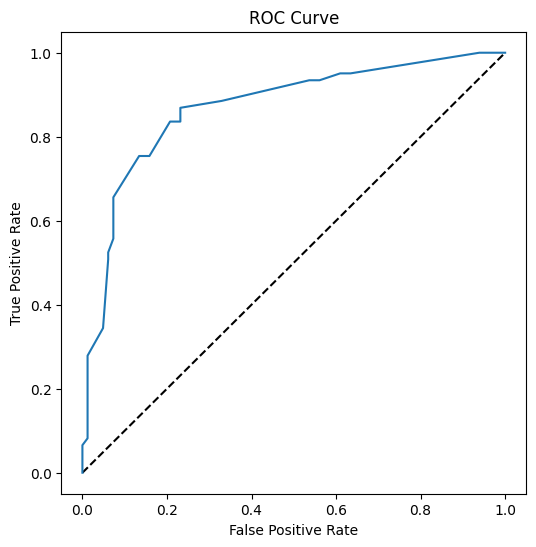

In [ ]:
# PLOT ROC CURVE TO EVALUATE MODEL PERFORMANCE
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

y_scores = model.predict_proba(X_test)
fpr, tpr, thresholds = roc_curve(y_test, y_scores[:,1])

fig = plt.figure(figsize=(6,6))
plt.plot([0,1], [0,1], "k--")
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()


In [ ]:
# CALCULATE ROC AUC SCORE
auc = roc_auc_score(y_test, y_scores[:,1])
auc

0.8691523390643743